# ACC2125 Group Project — Sydney Short-Term Rentals and Rail Access

**Group:** GroupXX
**City / snapshot:** Sydney, New South Wales, Australia — Inside Airbnb snapshot scraped 17–29 June 2026
**External dataset:** Transport for NSW, *Train station entrance locations* (2020, v4)

This notebook reproduces every number, table and figure used in `Report_GroupXX.docx` and `Slides_GroupXX.pptx`. Run it top to bottom from the project folder. Raw Inside Airbnb files are read from `data/`; the external dataset is read from `External_GroupXX.csv`. Figures are written to `figures/` at 300 DPI and headline numbers to `outputs/results.json`.

Structure:
- **Part A1** – data selection, external-data integration and the Data Decisions Log
- **Part A2** – guided questions Q1–Q3
- **Part A3** – two unguided analyses (transit premium; multi-listing hosts)
- **Part B** – three machine learning models (Ridge regression, K-Means, XGBoost + SHAP)

In [1]:
# ---- Imports and global settings ----
import json, re, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import geopandas as gpd
from scipy import stats
from sklearn.neighbors import BallTree
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

DATA = Path("data")                 # raw Inside Airbnb files
EXTERNAL = Path("External_GroupXX.csv")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
SEED = 42
RESULTS = {}                        # headline numbers exported for the report and slides

# Chart palette: validated categorical slots 1-3, a blue sequential ramp and recessive chrome
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
BLUE_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # ordinal steps 250-650
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
ORANGES = LinearSegmentedColormap.from_list("oranges", ["#fde3d6", "#f4a07a", "#eb6834", "#b8461a", "#7a2c0c"])

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": SURFACE, "savefig.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.6, "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.5, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "font.family": ["Segoe UI", "DejaVu Sans"], "font.size": 9, "legend.frameon": False,
    "legend.fontsize": 8, "lines.linewidth": 2,
})

def savefig(fig, name):
    """Save a figure at 300 DPI for the report and slides."""
    fig.savefig(FIG / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

def pct(x, d=1):
    return round(100 * float(x), d)

## Part A1 – Data selection and integration

### A1.1 Load the raw data
The Sydney snapshot gives a large, mature market (20,000+ listings) with strong commuter-rail coverage, which makes it a good setting to test whether rail access shows up in prices and demand. The external dataset is Transport for NSW's point locations of every station entrance on the NSW rail network (Sydney Trains, NSW TrainLink, Sydney Metro and light rail).

In [2]:
listings_raw = pd.read_csv(DATA / "listings.csv.gz")
calendar_raw = pd.read_csv(DATA / "calendar.csv.gz", parse_dates=["date"])
stations_raw = pd.read_csv(EXTERNAL)
lga_shapes = gpd.read_file(DATA / "neighbourhoods.geojson")

SNAPSHOT = pd.to_datetime(listings_raw["last_scraped"]).max()
summary = pd.DataFrame({
    "Dataset": ["listings.csv.gz", "calendar.csv.gz", "neighbourhoods.geojson", "External_GroupXX.csv"],
    "Source": ["Inside Airbnb", "Inside Airbnb", "Inside Airbnb", "Transport for NSW"],
    "Rows": [len(listings_raw), len(calendar_raw), len(lga_shapes), len(stations_raw)],
    "Columns": [listings_raw.shape[1], calendar_raw.shape[1], lga_shapes.shape[1], stations_raw.shape[1]],
})
print("Snapshot date:", SNAPSHOT.date())
print("Calendar covers", calendar_raw["date"].min().date(), "to", calendar_raw["date"].max().date())
RESULTS["snapshot"] = str(SNAPSHOT.date())
RESULTS["snapshot_start"] = str(pd.to_datetime(listings_raw["last_scraped"]).min().date())
RESULTS["raw_listings"] = len(listings_raw)
RESULTS["raw_calendar_rows"] = len(calendar_raw)
RESULTS["raw_station_rows"] = len(stations_raw)
RESULTS["raw_stations_unique"] = int(stations_raw["Train_Station"].nunique())
summary

Snapshot date: 2026-06-29
Calendar covers 2026-06-17 to 2027-06-28


,Dataset,Source,Rows,Columns
0,listings.csv.gz,Inside Airbnb,20573,90
1,calendar.csv.gz,Inside Airbnb,7509145,5
2,neighbourhoods.geojson,Inside Airbnb,38,3
3,External_GroupXX.csv,Transport for NSW,1074,7


### A1.2 Cleaning the listings and recording every decision
Each step below appends a row to the **Data Decisions Log** (Change Details / Reason and Justification), so the log always matches what the code actually did.

In [3]:
LOG = []
def log(change, reason):
    LOG.append({"Change Details": change, "Reason and Justification": reason})

df = listings_raw.copy()

# 1. Remove columns that are completely empty in this snapshot
empty_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=empty_cols)
log(f"Dropped {len(empty_cols)} columns that are 100% empty (e.g. host_since, host_response_rate, instant_bookable).",
    "These fields are not populated in the June 2026 Sydney snapshot, so they carry no information.")

# 2. Convert price text ("$1,234.00") to a number and drop listings without a price
df["price"] = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)
n_before = len(df)
df = df[df["price"].notna()]
log(f"Removed {n_before - len(df):,} listings with no nightly price ({len(df):,} remain).",
    "Price is the key outcome for Q2, Q3, A3 and all models. Listings without a price are mostly unbookable or inactive.")

# 3. Keep short-term listings only
n_before = len(df)
df = df[df["minimum_nights"] <= 30]
log(f"Removed {n_before - len(df):,} listings with minimum stay above 30 nights ({len(df):,} remain).",
    "These are mid/long-term rentals (most require 90+ nights). They price and book differently from short-term stays.")

# 4. Trim extreme prices (1st and 99th percentile)
p_lo, p_hi = df["price"].quantile([0.01, 0.99])
n_before = len(df)
df = df[df["price"].between(p_lo, p_hi)]
log(f"Removed {n_before - len(df):,} listings priced below ${p_lo:,.0f} or above ${p_hi:,.0f} per night (1st/99th percentiles).",
    "The raw maximum was over $50,000 a night, which looks like data entry errors or placeholder prices. Trimming stops a few points dominating means and regressions.")
RESULTS["price_trim"] = [round(p_lo, 2), round(p_hi, 2)]

# 5. Bathrooms: fill missing numeric values from the text field and flag shared bathrooms
def parse_bath(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if "half" in text:
        return 0.5
    m = re.search(r"\d+(\.\d+)?", text)
    return float(m.group()) if m else np.nan

n_missing_bath = int(df["bathrooms"].isna().sum())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms_text"].map(parse_bath))
df["bath_shared"] = df["bathrooms_text"].str.contains("shared", case=False, na=False).astype(int)
log(f"Filled {n_missing_bath:,} missing bathroom counts by parsing bathrooms_text; added a shared-bathroom flag.",
    "The text field holds the same information (e.g. '1.5 shared baths'), so parsing recovers values without guessing.")

# 6. Impute remaining structural gaps with the median for the same room type and guest capacity
struct = ["bedrooms", "beds", "bathrooms"]
n_missing = {c: int(df[c].isna().sum()) for c in struct}
for c in struct:
    df[c] = df[c].fillna(df.groupby(["room_type", "accommodates"])[c].transform("median"))
    df[c] = df[c].fillna(df[c].median())
log("Imputed missing bedrooms ({bedrooms:,}), beds ({beds:,}) and bathrooms ({bathrooms:,}) with the median of listings with the same room type and capacity.".format(**n_missing),
    "Guest capacity strongly predicts room counts. A grouped median keeps imputed values realistic and avoids dropping listings.")

# 7. Engineer simple listing features
df["amenities_count"] = df["amenities"].map(lambda s: len(json.loads(s)) if isinstance(s, str) else 0)
df["superhost"] = (df["host_is_superhost"] == "t").astype(int)
top_types = df["property_type"].value_counts().head(6).index
df["property_group"] = np.where(df["property_type"].isin(top_types), df["property_type"], "Other")
df["host_tier"] = pd.cut(df["calculated_host_listings_count"], [0, 1, 9, np.inf],
                         labels=["Single (1)", "Small multi (2-9)", "Commercial (10+)"])
df["rated"] = df["number_of_reviews"] >= 5
log("Created amenities_count, superhost flag, property_group (top 6 types + Other), host_tier (1 / 2-9 / 10+ listings) and a 'rated' flag (5+ reviews).",
    "These turn raw text and long-tail categories into variables the analysis and models can use. With fewer than 5 reviews a rating is too noisy to compare.")
log("Kept review-score gaps as missing (not imputed) for EDA; rating analyses use listings with 5+ reviews only.",
    f"{pct(df['review_scores_rating'].isna().mean())}% of listings have no rating because they have no reviews. Filling these in would invent guest opinions.")

print(f"Clean listing sample: {len(df):,} rows")
RESULTS["clean_listings"] = len(df)

Clean listing sample: 15,686 rows


### A1.3 Integrating the external dataset – Transport for NSW station entrances
The entrance file covers the whole NSW network. We keep entrances inside the Greater Sydney window (the listings' bounding box plus about 10 km). We then use a haversine BallTree to find, for every listing, the great-circle distance to the nearest station entrance and the number of distinct stations within 1 km. Distance to Town Hall (the CBD centre) is added as a control, so rail effects are not confused with plain centrality.

In [4]:
st = stations_raw.copy()
st["Entrance_Type"] = st["Entrance_Type"].str.strip().str.title()
st["mode"] = np.where(st["Train_Station"].str.endswith(" LR"), "Light rail", "Heavy rail / Metro")
lat_lo, lat_hi = df["latitude"].min() - 0.1, df["latitude"].max() + 0.1
lon_lo, lon_hi = df["longitude"].min() - 0.1, df["longitude"].max() + 0.1
n_before = len(st)
st = st[st["LAT"].between(lat_lo, lat_hi) & st["LONG"].between(lon_lo, lon_hi)]
st = st.drop_duplicates(subset=["LAT", "LONG"])
log(f"External data: kept {len(st):,} of {n_before:,} station entrances inside the Greater Sydney window ({st['Train_Station'].nunique()} stations); standardised Entrance_Type capitalisation; removed duplicate coordinates.",
    "Regional NSW stations (e.g. Newcastle, Aberdeen) can never be the nearest station to a Sydney listing. 'stairs' vs 'Stairs' was a spelling inconsistency.")

EARTH_R = 6_371_000  # metres
tree = BallTree(np.radians(st[["LAT", "LONG"]].values), metric="haversine")
X_rad = np.radians(df[["latitude", "longitude"]].values)
dist, idx = tree.query(X_rad, k=1)
df["dist_to_nearest_station_m"] = dist[:, 0] * EARTH_R
df["nearest_station"] = st["Train_Station"].values[idx[:, 0]]
within = tree.query_radius(X_rad, r=1000 / EARTH_R)
names = st["Train_Station"].values
df["stations_within_1km"] = [len(set(names[i])) for i in within]

# Distance to Town Hall (CBD centre) as a centrality control
def haversine_km(lat, lon, lat0=-33.8731, lon0=151.2065):
    lat, lon, lat0, lon0 = map(np.radians, [lat, lon, lat0, lon0])
    a = np.sin((lat - lat0) / 2) ** 2 + np.cos(lat) * np.cos(lat0) * np.sin((lon - lon0) / 2) ** 2
    return 2 * EARTH_R * np.arcsin(np.sqrt(a)) / 1000
df["dist_to_cbd_km"] = haversine_km(df["latitude"], df["longitude"])

BAND_LABELS = ["<500 m", "500 m-1 km", "1-2 km", ">2 km"]
df["transit_band"] = pd.cut(df["dist_to_nearest_station_m"], [0, 500, 1000, 2000, np.inf], labels=BAND_LABELS)
df["near_station"] = (df["dist_to_nearest_station_m"] < 500).astype(int)
log("Engineered dist_to_nearest_station_m, nearest_station, stations_within_1km, transit_band and dist_to_cbd_km by joining each listing to the station entrances.",
    "This turns the external dataset into listing-level features used in Q3, A3 and all three models.")

RESULTS["stations_sydney"] = int(st["Train_Station"].nunique())
RESULTS["entrances_sydney"] = len(st)
RESULTS["median_dist_station_m"] = round(df["dist_to_nearest_station_m"].median())
RESULTS["share_within_500m"] = pct((df["dist_to_nearest_station_m"] < 500).mean())
RESULTS["share_within_1km"] = pct((df["dist_to_nearest_station_m"] < 1000).mean())
print(df[["dist_to_nearest_station_m", "stations_within_1km", "dist_to_cbd_km"]].describe().round(1))
df["transit_band"].value_counts().sort_index()

       dist_to_nearest_station_m  stations_within_1km  dist_to_cbd_km
count                    15686.0              15686.0         15686.0
mean                      2372.2                  2.0            11.2
std                       3651.0                  3.5            10.8
min                          9.0                  0.0             0.1
25%                        388.6                  0.0             3.1
50%                        819.4                  1.0             7.0
75%                       2276.4                  2.0            15.4
max                      28084.4                 18.0            58.4


transit_band
<500 m        5172
500 m-1 km    3622
1-2 km        2462
>2 km         4430
Name: count, dtype: int64

### A1.4 Calendar – forward booking signal
The calendar has no prices in this snapshot, only availability. We use the 90 days after the snapshot date to calculate each listing's share of nights already unavailable. This is a forward-looking demand signal that complements Inside Airbnb's review-based `estimated_occupancy_l365d`.

In [5]:
cal = calendar_raw[(calendar_raw["date"] >= SNAPSHOT) & (calendar_raw["date"] < SNAPSHOT + pd.Timedelta(days=90))].copy()
cal["unavailable"] = (cal["available"] == "f").astype(int)
cal_sum = cal.groupby("listing_id").agg(cal_days=("date", "size"), unavailable_rate_90d=("unavailable", "mean")).reset_index()
df = df.merge(cal_sum, left_on="id", right_on="listing_id", how="left").drop(columns="listing_id")
log(f"Summarised calendar.csv.gz to one row per listing: share of unavailable nights in the 90 days after {SNAPSHOT.date()} (unavailable_rate_90d).",
    "The calendar has 7.5 million daily rows and no price. A listing-level 90-day share is a usable forward demand signal. Note that 'unavailable' mixes real bookings with host-blocked nights.")
RESULTS["calendar_match_share"] = pct(df["unavailable_rate_90d"].notna().mean())
print("Listings matched to calendar:", RESULTS["calendar_match_share"], "%")

Listings matched to calendar: 100.0 %


### A1.5 Data Decisions Log and exported files

In [6]:
decisions = pd.DataFrame(LOG)
decisions.index = decisions.index + 1
decisions.to_csv(OUT / "data_decisions_log.csv", index_label="Step")

export_cols = ["id", "name", "host_id", "host_tier", "calculated_host_listings_count", "superhost",
               "neighbourhood_cleansed", "latitude", "longitude", "property_type", "property_group", "room_type",
               "accommodates", "bedrooms", "beds", "bathrooms", "bath_shared", "amenities_count", "price",
               "minimum_nights", "availability_365", "number_of_reviews", "number_of_reviews_ltm",
               "estimated_occupancy_l365d", "estimated_revenue_l365d", "review_scores_rating",
               "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
               "review_scores_communication", "review_scores_location", "review_scores_value", "rated",
               "unavailable_rate_90d", "dist_to_nearest_station_m", "nearest_station", "stations_within_1km",
               "transit_band", "near_station", "dist_to_cbd_km"]
df[export_cols].to_csv("Data01_GroupXX.csv", index=False)
cal_sum.to_csv("Data02_GroupXX.csv", index=False)
with pd.option_context("display.max_colwidth", None):
    display(decisions)

,Change Details,Reason and Justification
1,"Dropped 13 columns that are 100% empty (e.g. host_since, host_response_rate, instant_bookable).","These fields are not populated in the June 2026 Sydney snapshot, so they carry no information."
2,"Removed 2,787 listings with no nightly price (17,786 remain).","Price is the key outcome for Q2, Q3, A3 and all models. Listings without a price are mostly unbookable or inactive."
3,"Removed 1,778 listings with minimum stay above 30 nights (16,008 remain).",These are mid/long-term rentals (most require 90+ nights). They price and book differently from short-term stays.
4,"Removed 322 listings priced below $65 or above $2,979 per night (1st/99th percentiles).","The raw maximum was over $50,000 a night, which looks like data entry errors or placeholder prices. Trimming stops a few points dominating means and regressions."
5,"Filled 1,221 missing bathroom counts by parsing bathrooms_text; added a shared-bathroom flag.","The text field holds the same information (e.g. '1.5 shared baths'), so parsing recovers values without guessing."
6,"Imputed missing bedrooms (2,060), beds (561) and bathrooms (15) with the median of listings with the same room type and capacity.",Guest capacity strongly predicts room counts. A grouped median keeps imputed values realistic and avoids dropping listings.
7,"Created amenities_count, superhost flag, property_group (top 6 types + Other), host_tier (1 / 2-9 / 10+ listings) and a 'rated' flag (5+ reviews).",These turn raw text and long-tail categories into variables the analysis and models can use. With fewer than 5 reviews a rating is too noisy to compare.
8,Kept review-score gaps as missing (not imputed) for EDA; rating analyses use listings with 5+ reviews only.,12.0% of listings have no rating because they have no reviews. Filling these in would invent guest opinions.
9,"External data: kept 836 of 1,074 station entrances inside the Greater Sydney window (249 stations); standardised Entrance_Type capitalisation; removed duplicate coordinates.","Regional NSW stations (e.g. Newcastle, Aberdeen) can never be the nearest station to a Sydney listing. 'stairs' vs 'Stairs' was a spelling inconsistency."
10,"Engineered dist_to_nearest_station_m, nearest_station, stations_within_1km, transit_band and dist_to_cbd_km by joining each listing to the station entrances.","This turns the external dataset into listing-level features used in Q3, A3 and all three models."


## Part A2 – Guided analysis
### Q1. What characterises the most popular listings?
**Definition of popularity.** We use Inside Airbnb's `estimated_occupancy_l365d` (nights booked in the past year, estimated from reviews). A listing is *popular* if it is in the top quartile of this measure. We check this definition against the independent calendar signal (share of the next 90 days already unavailable) and against reviews in the last 12 months.

In [7]:
q75 = df["estimated_occupancy_l365d"].quantile(0.75)
df["popular"] = df["estimated_occupancy_l365d"] >= q75
RESULTS["popular_threshold_nights"] = float(q75)
RESULTS["popular_n"] = int(df["popular"].sum())

rho_cal, _ = stats.spearmanr(df["estimated_occupancy_l365d"], df["unavailable_rate_90d"], nan_policy="omit")
rho_rev, _ = stats.spearmanr(df["estimated_occupancy_l365d"], df["number_of_reviews_ltm"])
RESULTS["rho_occ_calendar"] = round(rho_cal, 2)
RESULTS["rho_occ_reviews_ltm"] = round(rho_rev, 2)
print(f"Popular = occupancy >= {q75:.0f} nights; Spearman with 90-day unavailability = {rho_cal:.2f}, with reviews LTM = {rho_rev:.2f}")

def profile(g):
    rated = g[g["rated"]]
    return pd.Series({
        "Listings": len(g),
        "Median price (AUD)": g["price"].median(),
        "Median guests": g["accommodates"].median(),
        "Median bedrooms": g["bedrooms"].median(),
        "Median minimum nights": g["minimum_nights"].median(),
        "Median amenities": g["amenities_count"].median(),
        "Mean rating (5+ reviews)": rated["review_scores_rating"].mean(),
        "Superhost %": 100 * g["superhost"].mean(),
        "Entire home %": 100 * (g["room_type"] == "Entire home/apt").mean(),
        "Commercial host (10+) %": 100 * (g["host_tier"] == "Commercial (10+)").mean(),
        "Median distance to station (m)": g["dist_to_nearest_station_m"].median(),
        "Within 500 m of station %": 100 * g["near_station"].mean(),
        "Median days available (365)": g["availability_365"].median(),
        "Median 90-day unavailable %": 100 * g["unavailable_rate_90d"].median(),
    })

q1_table = pd.DataFrame({"Popular (top 25%)": profile(df[df["popular"]]),
                         "Other listings": profile(df[~df["popular"]])})
# Mann-Whitney U tests for numeric differences
tests = {}
for col in ["price", "accommodates", "minimum_nights", "amenities_count", "dist_to_nearest_station_m"]:
    tests[col] = stats.mannwhitneyu(df.loc[df["popular"], col], df.loc[~df["popular"], col]).pvalue
tests["review_scores_rating"] = stats.mannwhitneyu(df.loc[df["popular"] & df["rated"], "review_scores_rating"],
                                                   df.loc[~df["popular"] & df["rated"], "review_scores_rating"]).pvalue
print("Mann-Whitney p-values:", {k: f"{v:.1e}" for k, v in tests.items()})
q1_table.to_csv(OUT / "q1_profile.csv")
RESULTS["q1"] = q1_table.round(2).to_dict()
q1_table.round(1)

Popular = occupancy >= 120 nights; Spearman with 90-day unavailability = 0.11, with reviews LTM = 0.99
Mann-Whitney p-values: {'price': '3.0e-25', 'accommodates': '4.8e-02', 'minimum_nights': '6.8e-106', 'amenities_count': '1.5e-109', 'dist_to_nearest_station_m': '3.1e-47', 'review_scores_rating': '9.9e-28'}


,Popular (top 25%),Other listings
Listings,4088.0,11598.0
Median price (AUD),285.8,320.5
Median guests,4.0,4.0
Median bedrooms,1.0,2.0
Median minimum nights,1.0,2.0
Median amenities,44.0,38.0
Mean rating (5+ reviews),4.8,4.7
Superhost %,62.8,29.1
Entire home %,87.1,78.0
Commercial host (10+) %,29.7,40.6


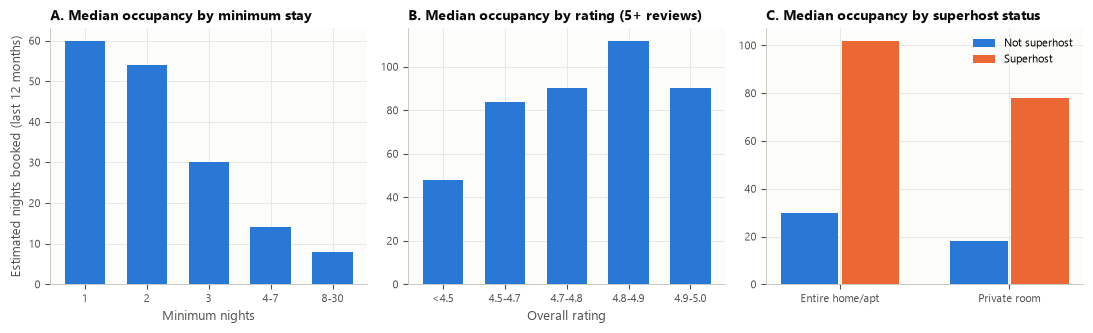

In [8]:
# Drivers of popularity: occupancy by minimum stay, by rating band and by superhost status
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))

mn_bins = pd.cut(df["minimum_nights"], [0, 1, 2, 3, 7, 30], labels=["1", "2", "3", "4-7", "8-30"])
s = df.groupby(mn_bins, observed=True)["estimated_occupancy_l365d"].median()
axes[0].bar(s.index.astype(str), s.values, color=C1, width=0.65)
axes[0].set_title("A. Median occupancy by minimum stay")
axes[0].set_xlabel("Minimum nights"); axes[0].set_ylabel("Estimated nights booked (last 12 months)")

rated = df[df["rated"]]
rb = pd.cut(rated["review_scores_rating"], [0, 4.5, 4.7, 4.8, 4.9, 5.0], labels=["<4.5", "4.5-4.7", "4.7-4.8", "4.8-4.9", "4.9-5.0"])
s = rated.groupby(rb, observed=True)["estimated_occupancy_l365d"].median()
axes[1].bar(s.index.astype(str), s.values, color=C1, width=0.65)
axes[1].set_title("B. Median occupancy by rating (5+ reviews)")
axes[1].set_xlabel("Overall rating")

s = df.groupby(["room_type", "superhost"])["estimated_occupancy_l365d"].median().unstack()
s = s.loc[["Entire home/apt", "Private room"]]
x = np.arange(len(s))
axes[2].bar(x - 0.18, s[0], width=0.34, color=C1, label="Not superhost")
axes[2].bar(x + 0.18, s[1], width=0.34, color=C2, label="Superhost")
axes[2].set_xticks(x, ["Entire home/apt", "Private room"])
axes[2].set_title("C. Median occupancy by superhost status")
axes[2].legend(loc="upper right")
fig.tight_layout()
savefig(fig, "q1_popularity_drivers")
RESULTS["q1_occ_by_minnights"] = df.groupby(mn_bins, observed=True)["estimated_occupancy_l365d"].median().to_dict()
RESULTS["q1_occ_by_rating"] = rated.groupby(rb, observed=True)["estimated_occupancy_l365d"].median().to_dict()
RESULTS["q1_occ_superhost"] = df.groupby("superhost")["estimated_occupancy_l365d"].median().to_dict()

In [9]:
# Room-type mix and property types among popular listings
mix = pd.crosstab(df["property_group"], df["popular"], normalize="columns").mul(100).round(1)
mix.columns = ["Other %", "Popular %"]
mix = mix.sort_values("Popular %", ascending=False)
RESULTS["q1_property_mix"] = mix.to_dict()
mix

,Other %,Popular %
property_group,,
Entire rental unit,46.6,54.2
Entire home,21.7,15.4
Other,11.5,15.0
Private room in home,11.8,5.5
Entire guesthouse,1.9,4.7
Entire condo,2.1,2.6
Private room in rental unit,4.4,2.6


**Q1 findings.** Popular listings (top 25%, at least 120 estimated nights a year) do not charge more. Their median price is $286 against $321 for the rest. What sets them apart is how they are run: 63% are superhosts (29% for other listings), the median minimum stay is 1 night (2 for others) and they offer more amenities (44 against 38). They are also slightly more often near rail (41% against 30% within 500 m). Commercial hosts are *under*-represented among them (30% against 41%). Occupancy falls steeply with minimum stay (60 nights at 1-night minimums against 8 nights at 8–30) and rises with rating up to 4.9.
*Caveat:* the occupancy estimate is built from review counts, so it agrees almost perfectly with reviews in the last 12 months (ρ = 0.99). It agrees only weakly with the 90-day calendar (ρ = 0.11), because 'unavailable' calendar nights include host blocks as well as bookings.

### Q2. How does price relate to guest ratings?
We use listings with 5 or more reviews so each rating reflects several guests. We report Spearman rank correlations (robust to skewed prices and the ceiling on ratings at 5), plot ratings across price deciles to look for non-linear patterns, and repeat the test within each room type so the room-type mix does not distort the result.

In [10]:
rated = df[df["rated"]].copy()
score_cols = ["review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
              "review_scores_communication", "review_scores_location", "review_scores_value"]
nice = {c: c.replace("review_scores_", "").title() for c in score_cols}
corr = rated[["price"] + score_cols].rename(columns={"price": "Price", **nice}).corr(method="spearman")
RESULTS["q2_n_rated"] = len(rated)
RESULTS["q2_spearman_price"] = corr.loc["Price"].drop("Price").round(3).to_dict()

rho, p = stats.spearmanr(rated["price"], rated["review_scores_rating"])
RESULTS["q2_rho_overall"] = round(rho, 3); RESULTS["q2_p_overall"] = float(p)
by_room = {}
for rt, g in rated.groupby("room_type"):
    if len(g) >= 100:
        r_, p_ = stats.spearmanr(g["price"], g["review_scores_rating"])
        by_room[rt] = {"n": len(g), "rho": round(r_, 3), "p": float(p_)}
RESULTS["q2_by_room"] = by_room
print(f"Overall Spearman rho(price, rating) = {rho:.3f} (p = {p:.1e}); by room type: {by_room}")

rated["price_decile"] = pd.qcut(rated["price"], 10, labels=False) + 1
dec = rated.groupby("price_decile").agg(price_median=("price", "median"), rating_mean=("review_scores_rating", "mean"),
                                        value_mean=("review_scores_value", "mean"), location_mean=("review_scores_location", "mean"),
                                        share_below_45=("review_scores_rating", lambda s: 100 * (s < 4.5).mean()))
kw = stats.kruskal(*[g["review_scores_rating"] for _, g in rated.groupby("price_decile")])
RESULTS["q2_kruskal_p"] = float(kw.pvalue)
RESULTS["q2_deciles"] = dec.round(3).reset_index().to_dict(orient="list")

# Linear vs quadratic trend of rating on log price
lin = smf.ols("review_scores_rating ~ np.log(price)", rated).fit()
quad = smf.ols("review_scores_rating ~ np.log(price) + I(np.log(price)**2)", rated).fit()
RESULTS["q2_linear_r2"] = round(lin.rsquared, 4); RESULTS["q2_quad_r2"] = round(quad.rsquared, 4)
RESULTS["q2_linear_slope"] = round(lin.params["np.log(price)"], 4)
print(f"Linear R2 = {lin.rsquared:.4f}, quadratic R2 = {quad.rsquared:.4f}; Kruskal-Wallis across deciles p = {kw.pvalue:.1e}")
dec.round(3)

Overall Spearman rho(price, rating) = 0.216 (p = 1.0e-116); by room type: {'Entire home/apt': {'n': 9058, 'rho': np.float64(0.16), 'p': 7.001068327441069e-53}, 'Private room': {'n': 1914, 'rho': np.float64(0.207), 'p': 5.712265822460488e-20}}
Linear R2 = 0.0583, quadratic R2 = 0.0618; Kruskal-Wallis across deciles p = 1.1e-131


,price_median,rating_mean,value_mean,location_mean,share_below_45
price_decile,,,,,
1,103.00,4.583,4.573,4.642,30.929
2,160.00,4.717,4.666,4.795,15.818
3,205.41,4.741,4.674,4.821,12.941
4,246.00,4.758,4.677,4.837,11.202
5,285.50,4.756,4.671,4.846,10.354
6,325.24,4.763,4.670,4.859,10.063
7,375.00,4.770,4.671,4.865,9.891
8,435.75,4.782,4.680,4.876,8.514
9,553.47,4.799,4.694,4.891,8.265


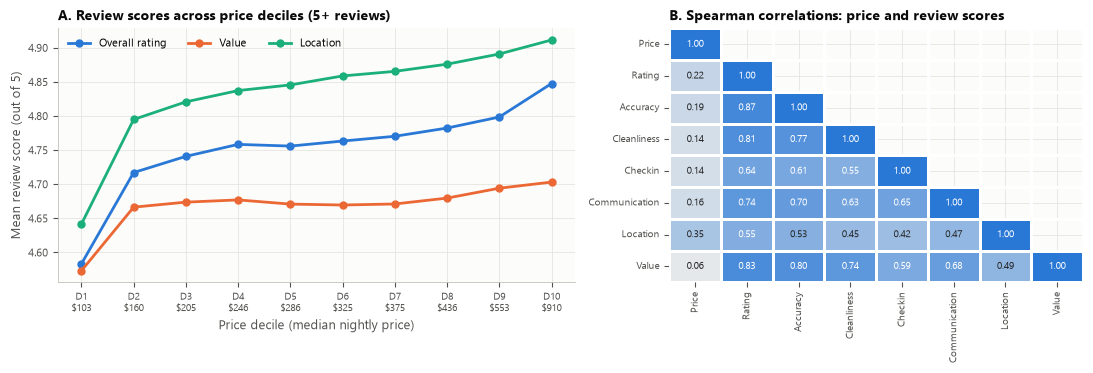

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.25, 1]})
# A. Rating, value and location scores across price deciles
ax = axes[0]
ax.plot(dec.index, dec["rating_mean"], color=C1, marker="o", markersize=5, label="Overall rating")
ax.plot(dec.index, dec["value_mean"], color=C2, marker="o", markersize=5, label="Value")
ax.plot(dec.index, dec["location_mean"], color=C3, marker="o", markersize=5, label="Location")
ax.set_xticks(dec.index, [f"D{i}\n${v:,.0f}" for i, v in zip(dec.index, dec["price_median"])], fontsize=7)
ax.set_xlabel("Price decile (median nightly price)")
ax.set_ylabel("Mean review score (out of 5)")
ax.set_title("A. Review scores across price deciles (5+ reviews)")
ax.legend(loc="upper left", ncols=3)
# B. Spearman correlation heatmap
ax = axes[1]
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"]),
            vmin=-1, vmax=1, cbar=False, ax=ax, annot_kws={"size": 7}, linewidths=1, linecolor="white")
ax.set_title("B. Spearman correlations: price and review scores")
ax.tick_params(labelsize=7)
fig.tight_layout()
savefig(fig, "q2_price_vs_rating")

**Q2 findings.** Price and rating are positively but weakly related (Spearman ρ = 0.22, n = 11,026). The relationship is non-linear: almost all the gain comes from leaving the cheapest decile (mean rating 4.58 at a median of $103, against 4.72 at $160), and it is flat in the middle. The share of listings rated below 4.5 falls from 31% in the cheapest decile to 4% in the dearest. Location is the sub-score most tied to price (ρ = 0.35), and Value the least (ρ = 0.06): guests at expensive listings are happier overall, but do not feel they get better value. A linear fit on log price explains only 5.8% of rating variation (6.2% with a quadratic term), so price is a weak signal of guest satisfaction.

### Q3. How is location associated with listing characteristics and performance?
Two lenses: (i) **local government areas (LGAs)**, the neighbourhood units Inside Airbnb uses; (ii) **rail access**, from the external station-entrance dataset.

In [12]:
lga = df.groupby("neighbourhood_cleansed").agg(
    listings=("id", "size"), median_price=("price", "median"), median_occupancy=("estimated_occupancy_l365d", "median"),
    mean_location_score=("review_scores_location", "mean"), entire_home_pct=("room_type", lambda s: 100 * (s == "Entire home/apt").mean()),
    median_dist_station_m=("dist_to_nearest_station_m", "median"), median_dist_cbd_km=("dist_to_cbd_km", "median"),
    commercial_pct=("host_tier", lambda s: 100 * (s == "Commercial (10+)").mean()))
lga_30 = lga[lga["listings"] >= 30].sort_values("median_price", ascending=False)
RESULTS["q3_lga_n"] = len(lga_30)
RESULTS["q3_lga_top_price"] = lga_30.head(5)[["listings", "median_price", "median_occupancy"]].round(1).to_dict(orient="index")
RESULTS["q3_lga_bottom_price"] = lga_30.tail(5)[["listings", "median_price", "median_occupancy"]].round(1).to_dict(orient="index")
RESULTS["q3_lga_top_occ"] = lga_30.sort_values("median_occupancy", ascending=False).head(5)[["listings", "median_price", "median_occupancy"]].round(1).to_dict(orient="index")
RESULTS["q3_sydney_lga_share"] = pct((df["neighbourhood_cleansed"] == "Sydney").mean())
RESULTS["q3_top5_lga_share"] = pct(df["neighbourhood_cleansed"].value_counts().head(5).sum() / len(df))

# Kruskal-Wallis: do price and occupancy differ by LGA?
big = df[df["neighbourhood_cleansed"].isin(lga_30.index)]
RESULTS["q3_kw_price_p"] = float(stats.kruskal(*[g["price"] for _, g in big.groupby("neighbourhood_cleansed")]).pvalue)
RESULTS["q3_kw_occ_p"] = float(stats.kruskal(*[g["estimated_occupancy_l365d"] for _, g in big.groupby("neighbourhood_cleansed")]).pvalue)
r_lga, p_lga = stats.spearmanr(lga_30["median_price"], lga_30["median_occupancy"])
RESULTS["q3_lga_price_occ_rho"] = round(r_lga, 2)
lga_30.round(1)

,listings,median_price,median_occupancy,mean_location_score,entire_home_pct,median_dist_station_m,median_dist_cbd_km,commercial_pct
neighbourhood_cleansed,,,,,,,,
Pittwater,673,702.0,18.0,4.9,95.2,13073.0,28.6,24.4
Manly,665,418.4,48.0,4.9,93.5,8603.3,11.1,29.8
Woollahra,405,409.5,42.0,4.9,88.6,912.4,3.3,35.8
Mosman,178,403.7,40.0,4.9,95.5,3572.7,6.2,36.5
Warringah,617,377.0,30.0,4.9,93.5,9976.2,14.1,14.3
Waverley,1289,364.0,48.0,4.9,89.0,2192.4,6.4,32.4
North Sydney,633,337.0,60.0,4.9,91.5,633.0,4.1,43.4
Sutherland Shire,415,335.0,66.0,4.9,88.2,1187.1,21.2,10.4
Camden,107,331.0,54.0,4.7,76.6,5524.5,45.1,24.3


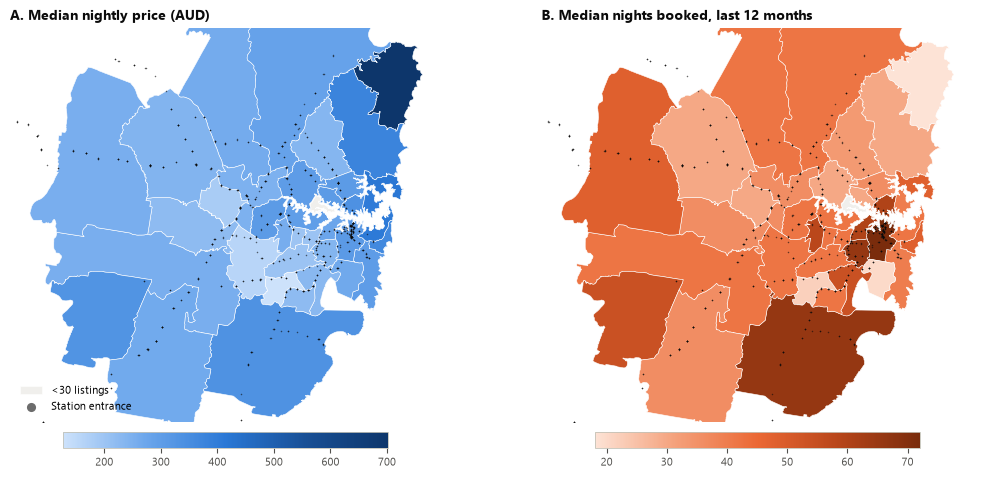

In [13]:
# Choropleth maps: median price and median occupancy by LGA, with station entrances overlaid
g = lga_shapes.merge(lga, left_on="neighbourhood", right_index=True, how="left")
g.loc[g["listings"] < 30, ["median_price", "median_occupancy"]] = np.nan
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, col, cmap, title in [(axes[0], "median_price", BLUES, "A. Median nightly price (AUD)"),
                             (axes[1], "median_occupancy", ORANGES, "B. Median nights booked, last 12 months")]:
    g.plot(column=col, cmap=cmap, linewidth=0.4, edgecolor="white", ax=ax, legend=True,
           missing_kwds={"color": "#f0efec", "label": "<30 listings"},
           legend_kwds={"shrink": 0.6, "orientation": "horizontal", "pad": 0.02})
    ax.scatter(st["LONG"], st["LAT"], s=1.2, color=INK, alpha=0.6, linewidths=0, label="Station entrance")
    ax.set_xlim(150.55, 151.38); ax.set_ylim(-34.18, -33.55)
    ax.set_axis_off(); ax.set_title(title)
axes[0].legend(loc="lower left", markerscale=6)
fig.tight_layout()
savefig(fig, "q3_lga_maps")

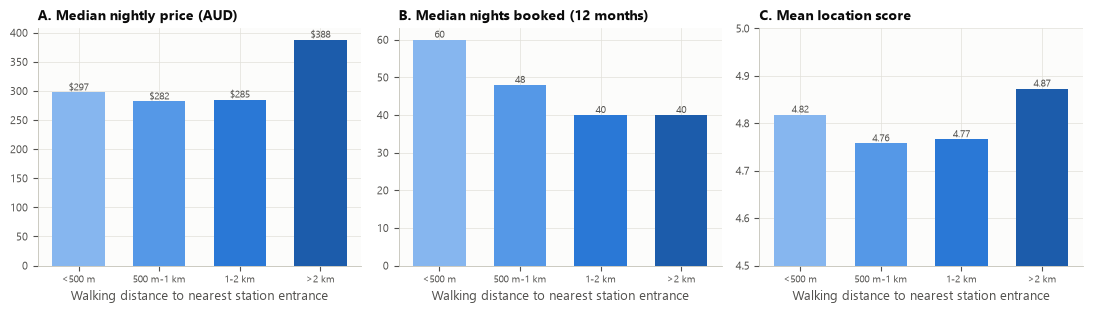

,listings,median_price,median_occupancy,mean_location_score,entire_home_pct,median_dist_cbd_km,unavailable_90d
transit_band,,,,,,,
<500 m,5172,297.41,60.0,4.82,80.59,2.93,0.32
500 m-1 km,3622,281.94,48.0,4.76,75.48,5.53,0.29
1-2 km,2462,285.14,40.0,4.77,72.99,7.24,0.26
>2 km,4430,388.00,40.0,4.87,88.17,11.82,0.23


In [14]:
# Rail-access bands: price, occupancy and location score
band = df.groupby("transit_band", observed=True).agg(
    listings=("id", "size"), median_price=("price", "median"), median_occupancy=("estimated_occupancy_l365d", "median"),
    mean_location_score=("review_scores_location", "mean"), entire_home_pct=("room_type", lambda s: 100 * (s == "Entire home/apt").mean()),
    median_dist_cbd_km=("dist_to_cbd_km", "median"), unavailable_90d=("unavailable_rate_90d", "median"))
RESULTS["q3_bands"] = band.round(2).reset_index().astype({"transit_band": str}).to_dict(orient="list")
for col in ["price", "estimated_occupancy_l365d", "review_scores_location"]:
    r_, p_ = stats.spearmanr(df["dist_to_nearest_station_m"], df[col], nan_policy="omit")
    RESULTS[f"q3_rho_dist_{col}"] = round(r_, 3)
r_, _ = stats.spearmanr(df["dist_to_cbd_km"], df["price"])
RESULTS["q3_rho_cbd_price"] = round(r_, 3)
r_, _ = stats.spearmanr(df["dist_to_cbd_km"], df["dist_to_nearest_station_m"])
RESULTS["q3_rho_cbd_station"] = round(r_, 3)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, col, title, fmt in [(axes[0], "median_price", "A. Median nightly price (AUD)", "${:,.0f}"),
                            (axes[1], "median_occupancy", "B. Median nights booked (12 months)", "{:,.0f}"),
                            (axes[2], "mean_location_score", "C. Mean location score", "{:.2f}")]:
    bars = ax.bar(band.index.astype(str), band[col], color=BLUE_RAMP[:4], width=0.65)
    ax.set_title(title)
    ax.set_xlabel("Walking distance to nearest station entrance")
    for b, v in zip(bars, band[col]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), fmt.format(v), ha="center", va="bottom", fontsize=7, color=INK2)
    ax.tick_params(axis="x", labelsize=7)
axes[2].set_ylim(4.5, 5.0)
fig.tight_layout()
savefig(fig, "q3_transit_bands")
band.round(2)

**Q3 findings.** Location strongly separates both price and demand (Kruskal-Wallis p < 0.001 for both across 37 LGAs). The dearest LGAs are coastal and northern (Pittwater median $702, Manly $418, Woollahra $410). The cheapest are south-western and southern (Hurstville $127, Bankstown $160). Demand follows a different map: the City of Sydney has the highest median occupancy (72 nights) at a mid-range price, while Pittwater, the dearest LGA, has one of the lowest (18 nights). Across LGAs, price and occupancy are almost unrelated (ρ = 0.13). Rail access is linked to **demand** more than price. Listings within 500 m of a station have the highest median occupancy (60 nights against 40 beyond 2 km) and the highest forward booking rate, but the *lowest* median prices. The listings more than 2 km from a station are the dearest ($388), because that band includes the beach suburbs.

## Part A3 – Unguided analysis
### Analysis 1: Is there a rail-access price premium once we control for what the listing is and where it is?
Q3 shows raw differences by distance band, but listings near stations also tend to be smaller, more central apartments. We estimate the premium with log-price OLS regressions (HC3 robust standard errors), adding controls one block at a time:
1. **Raw** – distance band only
2. **+ Listing structure** – room type, guests, bedrooms, bathrooms, shared bath, amenities
3. **+ Location controls** – distance to CBD and LGA fixed effects

The coefficient on each band (reference: more than 2 km) is converted to a percentage premium, `exp(b) - 1`.

In [15]:
ref = 'C(transit_band, Treatment(reference=">2 km"))'
specs = {
    "Raw": f"np.log(price) ~ {ref}",
    "+ Structure": f"np.log(price) ~ {ref} + C(room_type) + accommodates + bedrooms + bathrooms + bath_shared + amenities_count",
    "+ Structure + location": f"np.log(price) ~ {ref} + C(room_type) + accommodates + bedrooms + bathrooms + bath_shared + amenities_count + dist_to_cbd_km + C(neighbourhood_cleansed)",
}
prem_rows = []
fits = {}
for name, f in specs.items():
    m = smf.ols(f, df).fit(cov_type="HC3")
    fits[name] = m
    for b in BAND_LABELS[:3]:
        term = f'{ref}[T.{b}]'
        lo, hi = m.conf_int().loc[term]
        prem_rows.append({"Model": name, "Band": b, "Premium %": 100 * (np.exp(m.params[term]) - 1),
                          "CI low %": 100 * (np.exp(lo) - 1), "CI high %": 100 * (np.exp(hi) - 1),
                          "p": m.pvalues[term], "R2": m.rsquared})
prem = pd.DataFrame(prem_rows)
RESULTS["a3_premium"] = prem.round(4).to_dict(orient="list")

# Dollar value of the adjusted <500 m premium, evaluated at the median nightly price
adj = prem[(prem["Model"] == "+ Structure + location") & (prem["Band"] == "<500 m")].iloc[0]
RESULTS["a3_adj_premium_500"] = round(adj["Premium %"], 2)
RESULTS["a3_adj_premium_500_ci"] = [round(adj["CI low %"], 2), round(adj["CI high %"], 2)]
RESULTS["a3_adj_premium_500_dollars"] = round(df["price"].median() * adj["Premium %"] / 100, 2)
RESULTS["median_price"] = float(df["price"].median())
raw = prem[(prem["Model"] == "Raw") & (prem["Band"] == "<500 m")].iloc[0]
RESULTS["a3_raw_premium_500"] = round(raw["Premium %"], 2)
RESULTS["a3_r2"] = {k: round(v.rsquared, 3) for k, v in fits.items()}

# Does rail access also show up in demand? Same controls, occupancy as the outcome
occ = smf.ols(specs["+ Structure + location"].replace("np.log(price)", "estimated_occupancy_l365d") + " + np.log(price)", df).fit(cov_type="HC3")
t500 = f'{ref}[T.<500 m]'
RESULTS["a3_occ_500_nights"] = round(occ.params[t500], 2)
RESULTS["a3_occ_500_p"] = float(occ.pvalues[t500])
RESULTS["a3_occ_500_ci"] = [round(v, 2) for v in occ.conf_int().loc[t500]]
print(f"Occupancy effect within 500 m: {occ.params[t500]:.1f} nights (p = {occ.pvalues[t500]:.3f})")
prem.round(3)

Occupancy effect within 500 m: 4.8 nights (p = 0.038)


,Model,Band,Premium %,CI low %,CI high %,p,R2
0,Raw,<500 m,-30.190,-32.057,-28.272,0.000,0.068
1,Raw,500 m-1 km,-35.541,-37.470,-33.552,0.000,0.068
2,Raw,1-2 km,-32.260,-34.686,-29.744,0.000,0.068
3,+ Structure,<500 m,-12.549,-14.081,-10.990,0.000,0.634
4,+ Structure,500 m-1 km,-17.620,-19.181,-16.030,0.000,0.634
5,+ Structure,1-2 km,-17.116,-18.964,-15.226,0.000,0.634
6,+ Structure + location,<500 m,2.286,-0.338,4.980,0.088,0.700
7,+ Structure + location,500 m-1 km,-2.235,-4.740,0.336,0.088,0.700
8,+ Structure + location,1-2 km,-2.165,-4.602,0.334,0.089,0.700


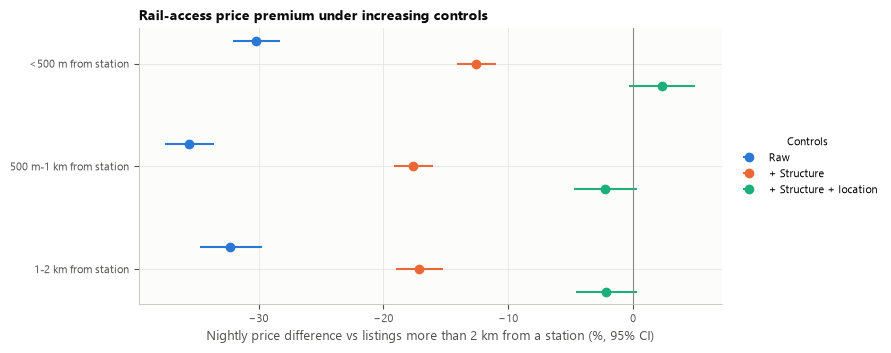

In [16]:
fig, ax = plt.subplots(figsize=(9, 3.6))
colors = {"Raw": C1, "+ Structure": C2, "+ Structure + location": C3}
offsets = {"Raw": -0.22, "+ Structure": 0.0, "+ Structure + location": 0.22}
for name, gdf_ in prem.groupby("Model", sort=False):
    y = np.arange(3) + offsets[name]
    ax.errorbar(gdf_["Premium %"], y, xerr=[gdf_["Premium %"] - gdf_["CI low %"], gdf_["CI high %"] - gdf_["Premium %"]],
                fmt="o", color=colors[name], markersize=6, capsize=0, elinewidth=1.5, label=name)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_yticks(np.arange(3), [f"{b} from station" for b in BAND_LABELS[:3]])
ax.invert_yaxis()
ax.set_xlabel("Nightly price difference vs listings more than 2 km from a station (%, 95% CI)")
ax.set_title("Rail-access price premium under increasing controls")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), title="Controls", title_fontsize=8)
fig.tight_layout()
savefig(fig, "a3_transit_premium")

**Analysis 1 findings.** The raw data shows a *discount*, not a premium: listings within 500 m of a station are 30% cheaper than those more than 2 km away. Adding listing structure halves this to −13%. Adding distance to the CBD and LGA fixed effects removes it: the adjusted difference is +2.3% (95% CI −0.3% to +5.0%, p = 0.09), worth about $7 a night at the median price. So the apparent "transit effect" on price is almost entirely a composition effect: who builds near stations (small apartments) and where stations are (not on the beaches). Rail proximity does show up in demand: with the same controls plus price, listings within 500 m book about 4.8 more nights a year (95% CI 0.3–9.3, p = 0.04).

### Analysis 2: Do commercial multi-listing hosts differ from single-listing hosts?
We split hosts by how many Sydney listings they run (`calculated_host_listings_count`): **single (1)**, **small multi (2–9)** and **commercial (10+)**. We compare guest satisfaction (overall and sub-scores), pricing, demand, rail access and operating patterns, using Kruskal-Wallis tests across the three tiers and Mann-Whitney tests between commercial and single hosts.

In [17]:
tier = df.groupby("host_tier", observed=True).agg(
    listings=("id", "size"), hosts=("host_id", "nunique"), median_price=("price", "median"),
    median_occupancy=("estimated_occupancy_l365d", "median"), median_availability=("availability_365", "median"),
    median_min_nights=("minimum_nights", "median"), superhost_pct=("superhost", lambda s: 100 * s.mean()),
    entire_home_pct=("room_type", lambda s: 100 * (s == "Entire home/apt").mean()),
    median_dist_station_m=("dist_to_nearest_station_m", "median"), within_500m_pct=("near_station", lambda s: 100 * s.mean()),
    median_dist_cbd_km=("dist_to_cbd_km", "median"), sydney_lga_pct=("neighbourhood_cleansed", lambda s: 100 * (s == "Sydney").mean()))
tier["listing_share_pct"] = 100 * tier["listings"] / tier["listings"].sum()
rated_t = df[df["rated"]]
sub = rated_t.groupby("host_tier", observed=True)[score_cols].mean().rename(columns=nice)
tier = tier.join(sub[["Rating"]].rename(columns={"Rating": "mean_rating_5plus"}))
tier["below_4_5_pct"] = rated_t.groupby("host_tier", observed=True)["review_scores_rating"].apply(lambda s: 100 * (s < 4.5).mean())

single = rated_t[rated_t["host_tier"] == "Single (1)"]
comm = rated_t[rated_t["host_tier"] == "Commercial (10+)"]
tests2 = {
    "rating_kw_p": stats.kruskal(*[g["review_scores_rating"] for _, g in rated_t.groupby("host_tier", observed=True)]).pvalue,
    "rating_mw_p": stats.mannwhitneyu(single["review_scores_rating"], comm["review_scores_rating"]).pvalue,
    "dist_mw_p": stats.mannwhitneyu(df.loc[df["host_tier"] == "Single (1)", "dist_to_nearest_station_m"],
                                    df.loc[df["host_tier"] == "Commercial (10+)", "dist_to_nearest_station_m"]).pvalue,
}
# Effect size: rank-biserial correlation for the rating comparison
u = stats.mannwhitneyu(single["review_scores_rating"], comm["review_scores_rating"]).statistic
tests2["rating_rank_biserial"] = 2 * u / (len(single) * len(comm)) - 1
chi = stats.chi2_contingency(pd.crosstab(df["host_tier"], df["near_station"]))
tests2["near_station_chi2_p"] = chi.pvalue

# Does the rating gap survive controls for room type, price, location and review volume?
m_gap = smf.ols('review_scores_rating ~ C(host_tier, Treatment(reference="Single (1)")) + C(room_type) + np.log(price) + np.log(number_of_reviews) + dist_to_cbd_km + C(neighbourhood_cleansed)', rated_t).fit(cov_type="HC3")
term = 'C(host_tier, Treatment(reference="Single (1)"))[T.Commercial (10+)]'
tests2["rating_gap_adj"] = m_gap.params[term]
tests2["rating_gap_adj_ci"] = list(m_gap.conf_int().loc[term])
tests2["rating_gap_adj_p"] = m_gap.pvalues[term]
RESULTS["a3_host_tier"] = tier.round(3).reset_index().astype({"host_tier": str}).to_dict(orient="list")
RESULTS["a3_host_subscores"] = sub.round(3).to_dict(orient="index")
RESULTS["a3_host_tests"] = {k: (float(v) if not isinstance(v, list) else [round(x, 4) for x in v]) for k, v in tests2.items()}
print({k: v for k, v in RESULTS["a3_host_tests"].items()})
tier.round(2).T

{'rating_kw_p': 0.0, 'rating_mw_p': 8.224477746387249e-308, 'dist_mw_p': 2.280141387456143e-197, 'rating_rank_biserial': 0.49822767055410755, 'near_station_chi2_p': 3.245718032129054e-92, 'rating_gap_adj': -0.16942005999356757, 'rating_gap_adj_ci': [-0.1797, -0.1591], 'rating_gap_adj_p': 5.030228869527542e-227}


host_tier,Single (1),Small multi (2-9),Commercial (10+)
listings,5011.00,4746.00,5929.00
hosts,5011.00,1604.00,259.00
median_price,331.00,279.59,319.53
median_occupancy,54.00,54.00,36.00
median_availability,171.00,189.00,176.00
median_min_nights,2.00,2.00,2.00
superhost_pct,40.13,45.11,30.17
entire_home_pct,89.14,71.70,79.86
median_dist_station_m,1464.78,794.08,625.46
within_500m_pct,22.41,34.34,40.80


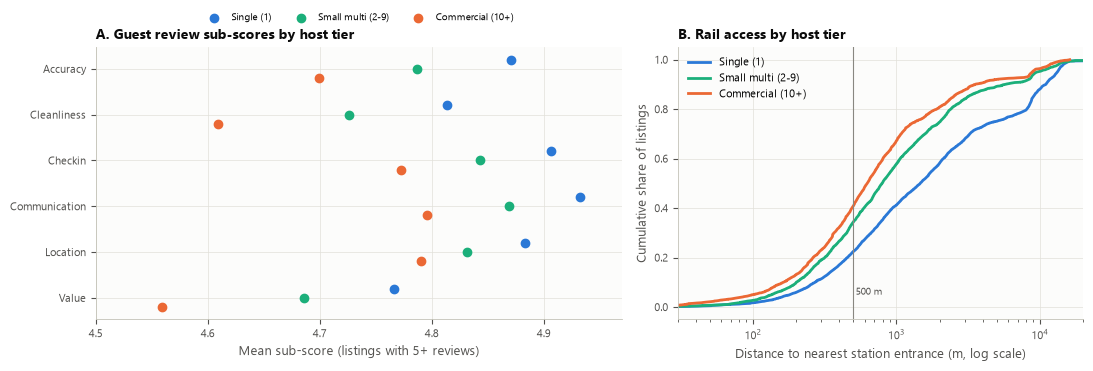

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
subs = sub.drop(columns=["Rating"]).T
tier_colors = {"Single (1)": C1, "Small multi (2-9)": C3, "Commercial (10+)": C2}
y = np.arange(len(subs))
for t, off in zip(subs.columns, [-0.2, 0, 0.2]):
    ax.scatter(subs[t], y + off, color=tier_colors[str(t)], s=36, label=str(t), zorder=3)
ax.set_yticks(y, subs.index)
ax.invert_yaxis()
ax.set_xlabel("Mean sub-score (listings with 5+ reviews)")
ax.set_title("A. Guest review sub-scores by host tier")
ax.set_xlim(4.5, 4.97)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.06), ncols=3, fontsize=7)

ax = axes[1]
for t in ["Single (1)", "Small multi (2-9)", "Commercial (10+)"]:
    d = np.sort(df.loc[df["host_tier"] == t, "dist_to_nearest_station_m"].values)
    ax.plot(d, np.arange(1, len(d) + 1) / len(d), color=tier_colors[t], label=t)
ax.axvline(500, color=MUTED, linewidth=0.8)
ax.text(520, 0.05, "500 m", fontsize=7, color=INK2)
ax.set_xscale("log"); ax.set_xlim(30, 20000)
ax.set_xlabel("Distance to nearest station entrance (m, log scale)")
ax.set_ylabel("Cumulative share of listings")
ax.set_title("B. Rail access by host tier")
ax.legend(loc="upper left")
fig.tight_layout()
savefig(fig, "a3_host_tiers")

**Analysis 2 findings.** Commercial hosts (10+ listings) are only 259 hosts, yet they run 38% of the short-term listings. Their guests rate them lower on every sub-score. The mean rating is 4.65 against 4.85 for single-listing hosts, and 22% of their listings sit below 4.5 against 4% for single hosts. The largest gap is in cleanliness (4.61 against 4.81). The gap survives controls for room type, price, review volume, distance to CBD and LGA: commercial listings are still 0.17 stars lower (95% CI −0.18 to −0.16). Commercial hosts are concentrated where rail access is best (median 625 m to a station against 1,465 m; 41% against 22% within 500 m). Even so, their median occupancy is lower (36 nights against 54). Better locations do not make up for weaker guest experience.

## Part B – Machine learning
All three models use the same cleaned sample and the same rail-access features from the external dataset. The supervised models predict **log nightly price**. Prices are strongly right-skewed, so a log target makes the errors proportional and stops luxury listings dominating the loss. Metrics are reported on the log scale (R²) and in dollars (RMSE, MAE) after back-transforming with `exp`. We use one fixed 80/20 train/test split (seed 42) for both supervised models, so the comparison is fair.

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, silhouette_score
from xgboost import XGBRegressor

TRANSIT = ["dist_to_nearest_station_m", "stations_within_1km"]
NUM = ["accommodates", "bedrooms", "beds", "bathrooms", "bath_shared", "amenities_count", "minimum_nights",
       "availability_365", "number_of_reviews", "review_scores_rating", "review_scores_location", "superhost",
       "calculated_host_listings_count", "latitude", "longitude", "dist_to_cbd_km"] + TRANSIT
CAT = ["room_type", "property_group", "neighbourhood_cleansed"]

model_df = df[NUM + CAT + ["price"]].copy()
model_df["log_price"] = np.log(model_df["price"])
# Ridge is linear, so give it log distances (diminishing effect of each extra metre); trees do not need this
model_df["log_dist_station"] = np.log1p(model_df["dist_to_nearest_station_m"])
model_df["log_dist_cbd"] = np.log1p(model_df["dist_to_cbd_km"])

train, test = train_test_split(model_df, test_size=0.2, random_state=SEED)
y_train, y_test = train["log_price"], test["log_price"]
RESULTS["ml_train_n"] = len(train); RESULTS["ml_test_n"] = len(test)

def evaluate(name, y_true_log, y_pred_log):
    yt, yp = np.exp(y_true_log), np.exp(y_pred_log)
    return {"Model": name, "R2 (log price)": r2_score(y_true_log, y_pred_log),
            "RMSE (AUD)": mean_squared_error(yt, yp) ** 0.5, "MAE (AUD)": mean_absolute_error(yt, yp),
            "MAPE %": 100 * np.mean(np.abs(yp - yt) / yt)}

# Naive baseline: predict the training median for everyone
baseline = evaluate("Baseline (median)", y_test, np.full(len(y_test), y_train.median()))
print(baseline)

{'Model': 'Baseline (median)', 'R2 (log price)': -0.0011931939399267844, 'RMSE (AUD)': 372.05422043365354, 'MAE (AUD)': 206.82956346025838, 'MAPE %': np.float64(58.12862781951774)}


### Model 1 (supervised, covered in class): Ridge regression
**How it works.** Ridge is ordinary least squares with an L2 penalty (α·Σβ²) that shrinks coefficients towards zero. This stabilises the estimates when predictors are correlated. Here bedrooms, beds and guests are highly collinear, and so are latitude, longitude and the distance measures.
**Objective.** Build an interpretable price model and measure how much rail access adds once structure and location are known.
**Preparation.** Median imputation plus missing-value indicators (unrated listings), standardisation of numeric features, one-hot encoding of room type, property group and LGA. The penalty α is tuned by 5-fold cross-validation on the training set.

In [20]:
NUM_R = [c for c in NUM if c not in ("dist_to_nearest_station_m", "dist_to_cbd_km")] + ["log_dist_station", "log_dist_cbd"]

def ridge_pipe(num_cols):
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)), ("sc", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), CAT)])
    return Pipeline([("pre", pre), ("model", Ridge())])

cv = KFold(5, shuffle=True, random_state=SEED)
ridge_search = GridSearchCV(ridge_pipe(NUM_R), {"model__alpha": np.logspace(-2, 3, 11)}, cv=cv,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
ridge_search.fit(train[NUM_R + CAT], y_train)
ridge = ridge_search.best_estimator_
m1 = evaluate("Model 1: Ridge", y_test, ridge.predict(test[NUM_R + CAT]))
m1_train = evaluate("Ridge (train)", y_train, ridge.predict(train[NUM_R + CAT]))
RESULTS["m1_alpha"] = float(ridge_search.best_params_["model__alpha"])
RESULTS["m1_cv_rmse_log"] = round(-ridge_search.best_score_, 4)
RESULTS["m1"] = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in m1.items()}
RESULTS["m1_train_r2"] = round(m1_train["R2 (log price)"], 4)

# Ablation: the same model without the two station features (shows what the external dataset adds)
NUM_R_noT = [c for c in NUM_R if c not in ("log_dist_station", "stations_within_1km")]
r_noT = GridSearchCV(ridge_pipe(NUM_R_noT), {"model__alpha": np.logspace(-2, 3, 11)}, cv=cv,
                     scoring="neg_root_mean_squared_error", n_jobs=-1).fit(train[NUM_R_noT + CAT], y_train)
m1_noT = evaluate("Ridge without rail features", y_test, r_noT.predict(test[NUM_R_noT + CAT]))
RESULTS["m1_noT"] = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in m1_noT.items()}

# Standardised coefficients
feat_names = ridge.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(ridge.named_steps["model"].coef_, index=feat_names)
coefs.index = coefs.index.str.replace("num__", "").str.replace("cat__", "")
RESULTS["m1_coef_rail"] = {k: round(coefs[k], 4) for k in ["log_dist_station", "stations_within_1km"]}
RESULTS["m1_top_coefs"] = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12).round(4).to_dict()
_nl = coefs[~coefs.index.str.startswith("neighbourhood_cleansed")]
RESULTS["m1_top_nonlga"] = _nl.reindex(_nl.abs().sort_values(ascending=False).index).head(12).round(4).to_dict()
RESULTS["m1_coef_cbd"] = round(coefs["log_dist_cbd"], 4)
print(f"Best alpha = {RESULTS['m1_alpha']}")
pd.DataFrame([baseline, m1_train, m1, m1_noT]).round(3)

Best alpha = 1.0


,Model,R2 (log price),RMSE (AUD),MAE (AUD),MAPE %
0,Baseline (median),-0.001,372.054,206.830,58.129
1,Ridge (train),0.732,232.071,118.397,27.447
2,Model 1: Ridge,0.732,235.503,118.926,27.124
3,Ridge without rail features,0.731,235.515,118.941,27.160


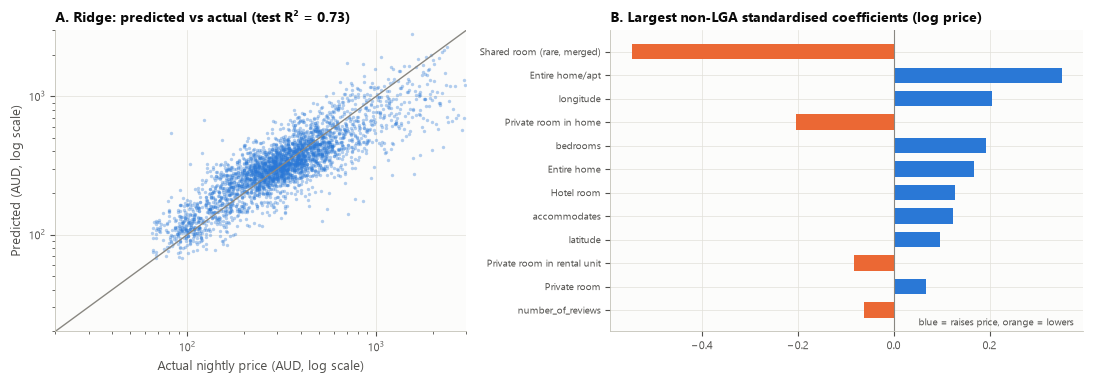

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), gridspec_kw={"width_ratios": [1, 1.15]})
ax = axes[0]
pred = ridge.predict(test[NUM_R + CAT])
ax.scatter(np.exp(y_test), np.exp(pred), s=6, alpha=0.35, color=C1, linewidths=0)
lims = [20, 3000]
ax.plot(lims, lims, color=MUTED, linewidth=1)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual nightly price (AUD, log scale)"); ax.set_ylabel("Predicted (AUD, log scale)")
ax.set_title(f"A. Ridge: predicted vs actual (test R² = {m1['R2 (log price)']:.2f})")
ax = axes[1]
READABLE = {"room_type_infrequent_sklearn": "Shared room (rare, merged)", "room_type_Hotel room": "Hotel room", "room_type_Entire home/apt": "Entire home/apt",
            "room_type_Private room": "Private room", "log_dist_station": "log distance to station (rail)",
            "stations_within_1km": "stations within 1 km (rail)", "log_dist_cbd": "log distance to CBD"}
non_lga = coefs[~coefs.index.str.startswith("neighbourhood_cleansed")]
top = non_lga.reindex(non_lga.abs().sort_values(ascending=False).index).head(12)[::-1]
top.index = [READABLE.get(i, i.replace("property_group_", "").replace("missingindicator_", "missing: ")) for i in top.index]
ax.barh(top.index, top.values, color=[C2 if v < 0 else C1 for v in top.values], height=0.65)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_title("B. Largest non-LGA standardised coefficients (log price)")
ax.tick_params(axis="y", labelsize=7)
ax.text(0.98, 0.02, "blue = raises price, orange = lowers", transform=ax.transAxes, ha="right", fontsize=7, color=INK2)
fig.tight_layout()
savefig(fig, "m1_ridge")

**Model 1 – issues encountered and limitations.**
- *Skewed target:* nightly price is strongly right-skewed (the raw maximum was over $50,000). Modelling log price makes the errors proportional and lets coefficients be read as approximate percentage effects.
- *Missing ratings:* 12% of listings have no review scores. Median imputation plus a missing-value indicator keeps them in the model, and the indicator captures the "unreviewed" effect.
- *Rare categories:* only 13 shared rooms remain after cleaning (and 49 hotel rooms), and dummies built on so few rows give unstable coefficients. `min_frequency=20` merges categories with fewer than 20 training rows (here, shared rooms) into one infrequent level.
- *Collinearity:* LGA dummies, latitude/longitude and distance to CBD carry overlapping information. As a result, some outer LGAs (e.g. Camden) receive large positive coefficients that only offset the distance terms. The L2 penalty keeps predictions stable, but individual location coefficients should not be read on their own.
- *Rail features:* removing the two station features changes test R² from 0.7316 to 0.7310. In a linear model, rail access adds almost no price information beyond LGA and CBD distance, which is consistent with Analysis 1.
- *Limitations:* the model is linear and additive (no interactions), the random split lets neighbouring listings sit in both train and test sets, and listed price is an asking price, not the price actually paid.

### Model 2 (unsupervised, covered in class): K-Means market segmentation
**How it works.** K-Means assigns each listing to the nearest of *k* centroids, then moves each centroid to the mean of its members. It repeats until assignments stop changing, which minimises within-cluster squared distance (inertia).
**Objective.** Segment Sydney's short-term rental supply into zones that combine location, price, rail access and demand, as a starting point for investment screening.
**Variables.** Latitude, longitude, log price, log distance to station, distance to CBD and estimated occupancy, all standardised so no single unit dominates. *k* is chosen with the elbow curve and the silhouette score (computed on a 4,000-listing random sample, because silhouette is O(n²)).

In [22]:
KM_FEATS = ["latitude", "longitude", "log_price", "log_dist_station", "dist_to_cbd_km", "estimated_occupancy_l365d"]
km_df = df[["latitude", "longitude", "price", "dist_to_nearest_station_m", "dist_to_cbd_km", "estimated_occupancy_l365d"]].copy()
km_df["log_price"] = np.log(km_df["price"]); km_df["log_dist_station"] = np.log1p(km_df["dist_to_nearest_station_m"])
Xk = StandardScaler().fit_transform(km_df[KM_FEATS])
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(Xk), 4000, replace=False)
k_rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Xk)
    k_rows.append({"k": k, "inertia": km.inertia_, "silhouette": silhouette_score(Xk[sample_idx], km.labels_[sample_idx])})
k_tab = pd.DataFrame(k_rows)
RESULTS["m2_k_table"] = k_tab.round(4).to_dict(orient="list")
k_tab.round(3)

,k,inertia,silhouette
0,2,72852.718,0.308
1,3,57290.874,0.319
2,4,47703.165,0.259
3,5,42668.868,0.216
4,6,38697.038,0.231
5,7,35780.468,0.220
6,8,33404.750,0.213
7,9,31421.042,0.218
8,10,29633.269,0.225


In [23]:
# Choose k: highest silhouette among k >= 4 (k = 2-3 only splits city vs suburbs, which is too coarse to act on)
best_k = int(k_tab.loc[k_tab["k"] >= 4].sort_values("silhouette", ascending=False).iloc[0]["k"])
km = KMeans(n_clusters=best_k, n_init=20, random_state=SEED).fit(Xk)
df["cluster"] = km.labels_
RESULTS["m2_k"] = best_k
RESULTS["m2_silhouette"] = round(float(k_tab.set_index("k").loc[best_k, "silhouette"]), 4)

prof = df.groupby("cluster").agg(listings=("id", "size"), median_price=("price", "median"),
                                 median_occupancy=("estimated_occupancy_l365d", "median"),
                                 median_revenue=("estimated_revenue_l365d", "median"),
                                 median_dist_station_m=("dist_to_nearest_station_m", "median"),
                                 median_dist_cbd_km=("dist_to_cbd_km", "median"),
                                 entire_home_pct=("room_type", lambda s: 100 * (s == "Entire home/apt").mean()),
                                 mean_rating=("review_scores_rating", "mean"),
                                 top_lga=("neighbourhood_cleansed", lambda s: ", ".join(s.value_counts().head(2).index)))
prof = prof.sort_values("median_dist_cbd_km")
names_map = {}
names_map[prof["median_occupancy"].idxmax()] = "City-core high-turnover"
names_map[prof["median_dist_station_m"].idxmax()] = "Coastal premium, rail-remote"
names_map[prof["median_dist_cbd_km"].idxmax()] = "Outer-suburban budget"
for c in prof.index:
    names_map.setdefault(c, "Inner-ring low-utilisation")
prof.insert(0, "segment", [names_map[c] for c in prof.index])
RESULTS["m2_profiles"] = prof.round(1).reset_index().to_dict(orient="list")
prof.round(1)

,segment,listings,median_price,median_occupancy,median_revenue,median_dist_station_m,median_dist_cbd_km,entire_home_pct,mean_rating,top_lga
cluster,,,,,,,,,,
3,City-core high-turnover,3520,278.3,186.0,51333.0,513.5,3.6,85.6,4.8,"Sydney, Waverley"
1,Inner-ring low-utilisation,7726,326.0,24.0,7337.0,669.0,5.7,80.5,4.7,"Sydney, Waverley"
2,"Coastal premium, rail-remote",2183,502.2,30.0,15180.0,9584.9,15.4,94.5,4.8,"Pittwater, Manly"
0,Outer-suburban budget,2257,203.5,36.0,6300.0,1116.8,25.9,58.0,4.6,"Parramatta, Blacktown"


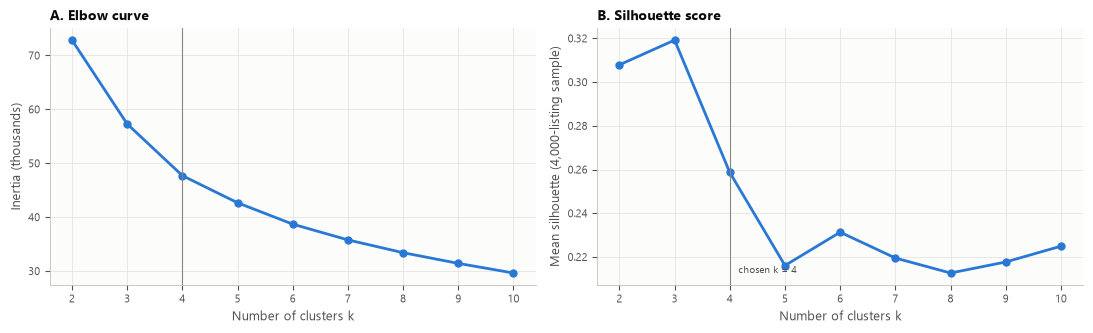

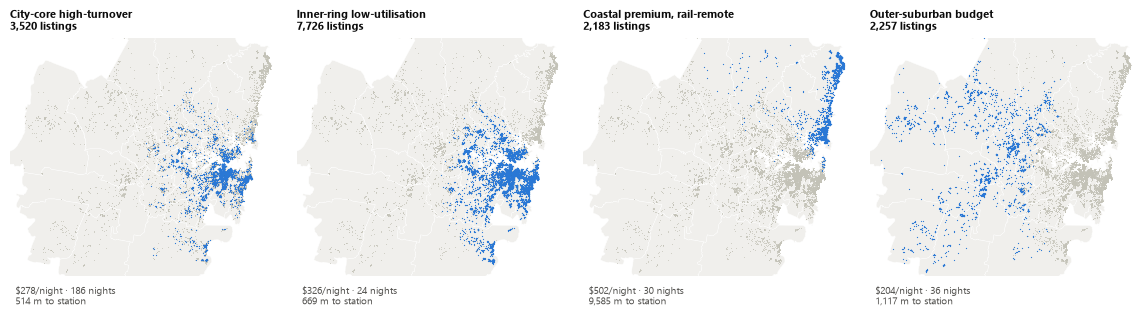

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(k_tab["k"], k_tab["inertia"] / 1000, color=C1, marker="o", markersize=5)
axes[0].axvline(best_k, color=MUTED, linewidth=0.8)
axes[0].set_xlabel("Number of clusters k"); axes[0].set_ylabel("Inertia (thousands)")
axes[0].set_title("A. Elbow curve")
axes[1].plot(k_tab["k"], k_tab["silhouette"], color=C1, marker="o", markersize=5)
axes[1].axvline(best_k, color=MUTED, linewidth=0.8)
axes[1].text(best_k + 0.1, k_tab["silhouette"].min(), f" chosen k = {best_k}", fontsize=7, color=INK2)
axes[1].set_xlabel("Number of clusters k"); axes[1].set_ylabel("Mean silhouette (4,000-listing sample)")
axes[1].set_title("B. Silhouette score")
fig.tight_layout()
savefig(fig, "m2_choose_k")

# Small multiples: one panel per cluster (avoids needing more than 3 distinguishable colours on a map)
order = prof.index.tolist()
ncol = min(best_k, 4); nrow = int(np.ceil(best_k / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.9 * ncol, 2.8 * nrow), squeeze=False)
for ax, c in zip(axes.flat, order):
    lga_shapes.plot(ax=ax, color="#f0efec", edgecolor="white", linewidth=0.3)
    ax.scatter(df["longitude"], df["latitude"], s=0.3, color="#c3c2b7", linewidths=0)
    sel = df[df["cluster"] == c]
    ax.scatter(sel["longitude"], sel["latitude"], s=0.8, color=C1, linewidths=0)
    p = prof.loc[c]
    ax.set_title(f"{p.segment}\n{int(p.listings):,} listings", fontsize=8)
    ax.text(0.02, -0.04, f"${p.median_price:,.0f}/night · {p.median_occupancy:.0f} nights\n{p.median_dist_station_m:,.0f} m to station",
            transform=ax.transAxes, fontsize=7, color=INK2, va="top")
    ax.set_xlim(150.6, 151.36); ax.set_ylim(-34.12, -33.56); ax.set_axis_off()
for ax in list(axes.flat)[best_k:]:
    ax.set_axis_off()
fig.tight_layout()
savefig(fig, "m2_cluster_maps")

**Model 2 – issues encountered and limitations.**
- *Runtime:* silhouette is O(n²). On 15,686 listings it is expensive to repeat for nine values of k, so it is computed on a fixed random sample of 4,000 listings.
- *Choice of k:* the silhouette score peaks at k = 3 (0.32), but that solution only separates the coast, the suburbs and the inner city. The elbow flattens after k = 4, and k = 4 splits the inner city into a high-turnover core and a low-utilisation ring, which is the distinction most useful to investors. We accept a lower silhouette (0.26) for that interpretability.
- *Scaling:* the features are on very different scales (occupancy 0–255 nights against coordinates that vary by fractions of a degree), so unscaled K-Means would cluster almost only on occupancy. All features are z-scored first.
- *Limitations:* K-Means assumes round, equally sized clusters, and silhouettes around 0.26 mean the segments overlap. Latitude and longitude are treated as Euclidean. Results depend on the chosen features, so the segments are a screening tool, not natural boundaries.

### Model 3 (not covered in class): XGBoost regressor with SHAP interpretation
**How it works.** XGBoost (Chen & Guestrin, 2016) builds an ensemble of shallow decision trees by gradient boosting. Each new tree is fitted to the residual errors of the trees so far, and its contribution is scaled by a learning rate. Regularisation (L2 on leaf weights, minimum child weight, row and column subsampling) controls overfitting. Unlike Ridge, it captures non-linear effects and interactions, such as rail access mattering more in some areas than others, without these being specified by hand.
**Interpretation.** SHAP (Lundberg & Lee, 2017) splits each prediction into additive feature contributions based on Shapley values from cooperative game theory. Because the target is log price, a SHAP value *s* means the feature changes the predicted price by about `exp(s) - 1` per cent.
**Objective.** Improve on Ridge's predictive accuracy and isolate the non-linear contribution of rail proximity to price.
**Tuning.** Randomised search (30 candidates, 3-fold CV on the training set) over depth, learning rate, number of trees, subsampling and regularisation.

In [25]:
def xgb_pipe(num_cols, **params):
    pre = ColumnTransformer([("num", "passthrough", num_cols),
                             ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False), CAT)])
    return Pipeline([("pre", pre), ("model", XGBRegressor(tree_method="hist", random_state=SEED, n_jobs=-1, **params))])

param_dist = {"model__n_estimators": [300, 500, 800, 1200], "model__max_depth": [4, 5, 6, 8],
              "model__learning_rate": [0.02, 0.03, 0.05, 0.08], "model__subsample": [0.7, 0.8, 0.9],
              "model__colsample_bytree": [0.6, 0.8, 1.0], "model__min_child_weight": [1, 3, 5, 10],
              "model__reg_lambda": [0.5, 1, 3, 10]}
t0 = time.time()
xgb_search = RandomizedSearchCV(xgb_pipe(NUM), param_dist, n_iter=30, cv=KFold(3, shuffle=True, random_state=SEED),
                                scoring="neg_root_mean_squared_error", random_state=SEED, n_jobs=1)
xgb_search.fit(train[NUM + CAT], y_train)
xgb = xgb_search.best_estimator_
RESULTS["m3_search_seconds"] = round(time.time() - t0, 1)
m3 = evaluate("Model 3: XGBoost", y_test, xgb.predict(test[NUM + CAT]))
m3_train = evaluate("XGBoost (train)", y_train, xgb.predict(train[NUM + CAT]))
RESULTS["m3_params"] = {k.replace("model__", ""): v for k, v in xgb_search.best_params_.items()}
RESULTS["m3_cv_rmse_log"] = round(-xgb_search.best_score_, 4)
RESULTS["m3"] = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in m3.items()}
RESULTS["m3_train_r2"] = round(m3_train["R2 (log price)"], 4)

# Ablation without rail features, same tuned hyper-parameters
NUM_noT = [c for c in NUM if c not in TRANSIT]
best = {k.replace("model__", ""): v for k, v in xgb_search.best_params_.items()}
xgb_noT = xgb_pipe(NUM_noT, **best).fit(train[NUM_noT + CAT], y_train)
m3_noT = evaluate("XGBoost without rail features", y_test, xgb_noT.predict(test[NUM_noT + CAT]))
RESULTS["m3_noT"] = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in m3_noT.items()}

compare = pd.DataFrame([baseline, m1, m1_noT, m3, m3_noT])
compare.to_csv(OUT / "model_comparison.csv", index=False)
print("Best parameters:", RESULTS["m3_params"])
compare.round(3)

Best parameters: {'subsample': 0.9, 'reg_lambda': 3, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


,Model,R2 (log price),RMSE (AUD),MAE (AUD),MAPE %
0,Baseline (median),-0.001,372.054,206.830,58.129
1,Model 1: Ridge,0.732,235.503,118.926,27.124
2,Ridge without rail features,0.731,235.515,118.941,27.160
3,Model 3: XGBoost,0.806,198.179,99.973,22.664
4,XGBoost without rail features,0.805,198.385,100.188,22.701


In [26]:
# SHAP values on the test set
import shap
pre = xgb.named_steps["pre"]; booster_model = xgb.named_steps["model"]
X_test_t = pre.transform(test[NUM + CAT])
names_t = [n.replace("num__", "").replace("cat__", "") for n in pre.get_feature_names_out()]
explainer = shap.TreeExplainer(booster_model)
shap_vals = explainer.shap_values(X_test_t)
shap_df = pd.DataFrame(shap_vals, columns=names_t, index=test.index)

# Group one-hot columns back to their original variable
def base_name(n):
    for c in CAT:
        if n.startswith(c + "_"):
            return c
    return n
grouped = shap_df.abs().T.groupby(base_name).sum().T.mean().sort_values(ascending=False)
RESULTS["m3_shap_mean_abs"] = grouped.round(4).to_dict()
rail_share = grouped[TRANSIT].sum() / grouped.sum()
RESULTS["m3_shap_rail_share_pct"] = pct(rail_share)
RESULTS["m3_shap_rail_rank"] = int(grouped.index.get_loc("dist_to_nearest_station_m")) + 1

# Average price effect of station distance by band (from SHAP, in % terms)
sd = pd.DataFrame({"dist": test["dist_to_nearest_station_m"], "shap": shap_df["dist_to_nearest_station_m"]})
sd["band"] = pd.cut(sd["dist"], [0, 250, 500, 1000, 2000, 5000, np.inf],
                    labels=["<250 m", "250-500 m", "500 m-1 km", "1-2 km", "2-5 km", ">5 km"])
shap_band = sd.groupby("band", observed=True)["shap"].mean().apply(lambda s: 100 * (np.exp(s) - 1))
RESULTS["m3_shap_dist_band_pct"] = shap_band.round(2).to_dict()
grouped.head(12)

C:\Users\teotz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


bedrooms                  0.180317
accommodates              0.137408
room_type                 0.121591
longitude                 0.108253
bathrooms                 0.053814
property_group            0.047561
dist_to_cbd_km            0.037067
amenities_count           0.034784
number_of_reviews         0.033320
review_scores_location    0.033081
latitude                  0.032209
minimum_nights            0.030142
dtype: float32

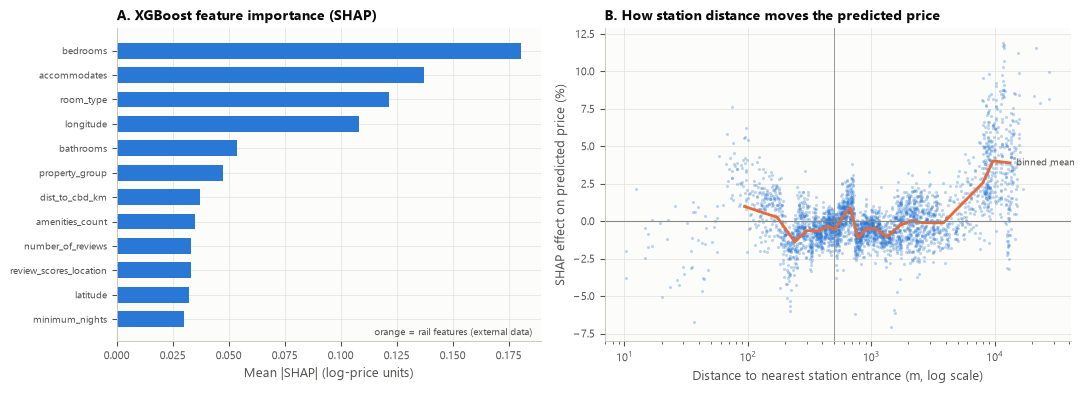

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), gridspec_kw={"width_ratios": [1, 1.1]})
ax = axes[0]
top = grouped.head(12)[::-1]
ax.barh(top.index, top.values, color=[C2 if i in TRANSIT else C1 for i in top.index], height=0.65)
ax.set_xlabel("Mean |SHAP| (log-price units)")
ax.set_title("A. XGBoost feature importance (SHAP)")
ax.tick_params(axis="y", labelsize=7)
ax.text(0.98, 0.02, "orange = rail features (external data)", transform=ax.transAxes, ha="right", fontsize=7, color=INK2)

ax = axes[1]
ax.scatter(sd["dist"], 100 * (np.exp(sd["shap"]) - 1), s=5, alpha=0.3, color=C1, linewidths=0)
binned = sd.assign(b=pd.qcut(np.log(sd["dist"]), 20)).groupby("b", observed=True).agg(d=("dist", "median"), s=("shap", "mean"))
ax.plot(binned["d"], 100 * (np.exp(binned["s"]) - 1), color=C2, linewidth=2)
ax.text(binned["d"].iloc[-1], 100 * (np.exp(binned["s"].iloc[-1]) - 1), "  binned mean", color=INK2, fontsize=7, va="center")
ax.axhline(0, color=MUTED, linewidth=0.8)
ax.axvline(500, color=MUTED, linewidth=0.6)
ax.set_xscale("log")
ax.set_xlabel("Distance to nearest station entrance (m, log scale)")
ax.set_ylabel("SHAP effect on predicted price (%)")
ax.set_title("B. How station distance moves the predicted price")
fig.tight_layout()
savefig(fig, "m3_shap")

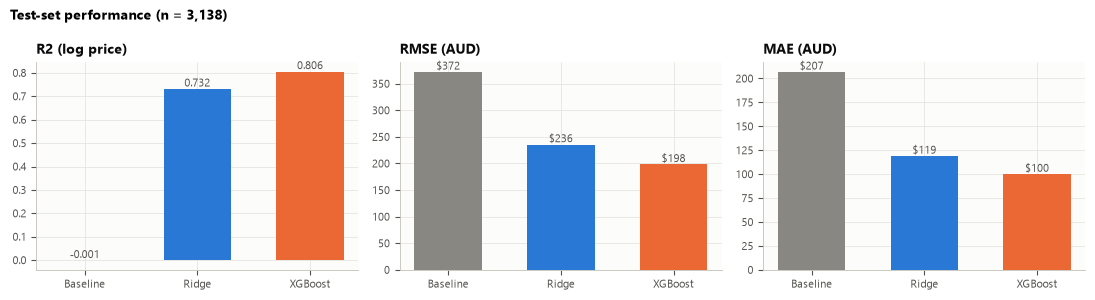

In [28]:
# Model comparison chart
fig, axes = plt.subplots(1, 3, figsize=(11, 3.0))
show = compare.set_index("Model").loc[["Baseline (median)", "Model 1: Ridge", "Model 3: XGBoost"]]
labels = ["Baseline", "Ridge", "XGBoost"]
for ax, col, fmt in [(axes[0], "R2 (log price)", "{:.3f}"), (axes[1], "RMSE (AUD)", "${:,.0f}"), (axes[2], "MAE (AUD)", "${:,.0f}")]:
    bars = ax.bar(labels, show[col], color=[MUTED, C1, C2], width=0.6)
    for b, v in zip(bars, show[col]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), fmt.format(v), ha="center", va="bottom", fontsize=8, color=INK2)
    ax.set_title(col)
fig.suptitle("Test-set performance (n = {:,})".format(len(test)), x=0.01, ha="left", fontsize=10, fontweight="bold")
fig.tight_layout()
savefig(fig, "ml_comparison")

**Model 3 – issues encountered and limitations.**
- *Overfitting:* the tuned model shows a train/test gap (train R² 0.91 against test 0.81), so the search favoured `min_child_weight`, `subsample`, `colsample_bytree` and `reg_lambda` settings that limit it. The cross-validated RMSE (0.309 log units) is close to the test result, so the test score is not a lucky split.
- *Fragmented importance:* SHAP spreads one-hot categories over many columns, which makes LGA and room type look less important than they are. We sum SHAP values back to the original variable before ranking.
- *Rail features:* they rank 19th and account for only 1.9% of total |SHAP|. The SHAP effect of station distance is within ±1% of price below 4 km. It rises only for listings more than 5 km from rail (+3.4% on average), which are mainly coastal Northern Beaches homes, so this is a location effect the station distance happens to pick up. Removing rail features changes test R² from 0.8059 to 0.8045.
- *Limitations:* SHAP describes what the model learned, not causal effects. Predictions shrink towards the middle (over-predicting the cheapest quartile by about 21% and under-predicting the dearest by about 13%), and the hyper-parameter search covered 30 of many possible combinations.

### Error analysis – where do the models miss?

In [29]:
err = test[["room_type", "neighbourhood_cleansed"]].copy()
err["actual"] = np.exp(y_test)
err["ridge"] = np.exp(ridge.predict(test[NUM_R + CAT])); err["xgb"] = np.exp(xgb.predict(test[NUM + CAT]))
err["price_band"] = pd.qcut(err["actual"], 4, labels=["Q1 (cheapest)", "Q2", "Q3", "Q4 (dearest)"])
err_tab = err.groupby("price_band", observed=True).apply(
    lambda g: pd.Series({"Ridge MAPE %": 100 * np.mean(np.abs(g.ridge - g.actual) / g.actual),
                         "XGBoost MAPE %": 100 * np.mean(np.abs(g.xgb - g.actual) / g.actual),
                         "XGBoost bias %": 100 * np.mean((g.xgb - g.actual) / g.actual)}))
RESULTS["ml_err_by_band"] = err_tab.round(2).to_dict()
err_tab.round(1)

,Ridge MAPE %,XGBoost MAPE %,XGBoost bias %
price_band,,,
Q1 (cheapest),35.0,26.5,20.7
Q2,23.5,19.8,10.8
Q3,20.0,18.3,-0.4
Q4 (dearest),30.1,26.1,-12.5


In [30]:
# Export headline numbers for the report and slides
def clean(o):
    if isinstance(o, dict):
        return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        return None if np.isnan(o) else float(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o
(OUT / "results.json").write_text(json.dumps(clean(RESULTS), indent=2))
print("Saved", len(RESULTS), "result groups and", len(list(FIG.glob("*.png"))), "figures")

Saved 87 result groups and 11 figures
